# One-Shot Percussion Classification — 42 Features

Multi-run training (N = 5) with different random seeds on the same train/validation split. Reports mean ± std over runs and saves the best-performing model for downstream feature-importance and embedding-space analysis.

**Outputs saved to Drive:**
- `best_42feats.h5` — model of the best-performing run
- `runs_summary_42feats.csv` — per-run metrics
- `all_histories.pkl` — training histories for all 5 runs
- `best_run_history.pkl` — training history of the best run


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Imports and global config

In [3]:
import os, random, pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score
)
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# PATHS — edit to match your Drive layout
# ------------------------------------------------------------------
CSV_PATH = '/content/drive/MyDrive/Feature Importance Analysis/one_shot_features_clean_V4.csv'
SAVE_DIR = '/content/drive/MyDrive/SavedModels/42feats_runs'
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------------
# EXPERIMENT CONFIG
# ------------------------------------------------------------------
RUN_SEEDS   = [42, 123, 7, 2024, 512]   # one seed per run
N_RUNS      = len(RUN_SEEDS)
SPLIT_SEED  = 42                        # fixed for all runs
TEST_SIZE   = 0.2
EPOCHS      = 200
BATCH_SIZE  = 32
LR_INIT     = 1e-3
PATIENCE_ES = 15
PATIENCE_LR = 8
DROPOUT     = 0.3


## 2. Data loading and preprocessing
Null values in numeric columns are imputed with the column-wise mean, consistent with the preprocessing described in the paper.

In [4]:
df = pd.read_csv(CSV_PATH)

print('Null values (before imputation):')
print(df.isnull().sum()[df.isnull().sum() > 0])

df_filled = df.copy()
numeric_columns = df.select_dtypes(include=[np.number]).columns
df_filled[numeric_columns] = (
    df_filled[numeric_columns].fillna(df_filled[numeric_columns].mean())
)

print(f'\nDataset size: {len(df_filled)} samples')
print(f'Class distribution:\n{df_filled["label"].value_counts()}')


Null values (before imputation):
hpi_ratio    62
dtype: int64

Dataset size: 6435 samples
Class distribution:
label
Snare     1445
Bass      1210
Kick      1205
Hat       1049
Clap       572
Cymbal     480
Rims       474
Name: count, dtype: int64


In [5]:
# Features and labels
feature_cols = [c for c in df_filled.columns if c not in ('label', 'filename')]
X = df_filled[feature_cols].values
y = df_filled['label'].values

print(f'Feature matrix: {X.shape}')
print(f'Number of features: {len(feature_cols)}')

# Label encoding
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = tf.keras.utils.to_categorical(y_encoded)
num_classes = len(label_encoder.classes_)
class_names = list(label_encoder.classes_)
print(f'Classes: {class_names}')


Feature matrix: (6435, 42)
Number of features: 42
Classes: ['Bass', 'Clap', 'Cymbal', 'Hat', 'Kick', 'Rims', 'Snare']


In [6]:
# z-score normalization — fit on ALL data (consistent with paper)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fixed train/validation split for ALL runs
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_categorical,
    test_size=TEST_SIZE,
    random_state=SPLIT_SEED,
    stratify=y_encoded,
)

print(f'Train set: {X_train.shape}, Val set: {X_test.shape}')


Train set: (5148, 42), Val set: (1287, 42)


## 3. Model architecture
Three fully connected hidden blocks (256, 128, 64) each with BN + Dropout(0.3) + ReLU, followed by a 64-unit embedding layer and a softmax classifier.

In [7]:
def create_enhanced_model(input_dim, num_classes, dropout=DROPOUT):
    inp = Input(shape=(input_dim,), name='input_layer')

    x = Dense(256, activation='relu', name='dense_1')(inp)
    x = BatchNormalization(name='bn_1')(x)
    x = Dropout(dropout, name='dropout_1')(x)

    x = Dense(128, activation='relu', name='dense_2')(x)
    x = BatchNormalization(name='bn_2')(x)
    x = Dropout(dropout, name='dropout_2')(x)

    x = Dense(64, activation='relu', name='dense_3')(x)
    x = BatchNormalization(name='bn_3')(x)
    x = Dropout(dropout, name='dropout_3')(x)

    embedding = Dense(64, activation='relu', name='embedding_layer')(x)
    output = Dense(num_classes, activation='softmax', name='output_layer')(embedding)

    model = Model(inputs=inp, outputs=output, name='enhanced_audio_classifier')
    model.compile(
        optimizer=Adam(learning_rate=LR_INIT),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

# Quick sanity check
test_model = create_enhanced_model(X_scaled.shape[1], num_classes)
test_model.summary()
del test_model


Model: "enhanced_audio_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        11,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_layer (Dense)         │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,567 (228.78 KB)

 Trainable params: 57,671 (225.28 KB)

 Non-trainable params: 896 (3.50 KB)

## 4. Helper function — single training run
Seeds all sources of randomness, trains one model, saves its checkpoint, and returns metrics + history.

In [8]:
def set_all_seeds(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)


def run_one(run_id, seed, X_tr, y_tr, X_va, y_va):
    print(f'\n{"="*60}')
    print(f'RUN {run_id+1}/{N_RUNS}  |  seed = {seed}')
    print('=' * 60)

    tf.keras.backend.clear_session()
    set_all_seeds(seed)

    model = create_enhanced_model(X_tr.shape[1], num_classes)
    ckpt_path = f'{SAVE_DIR}/run{run_id+1}_seed{seed}.h5'

    callbacks = [
        EarlyStopping(
            monitor='val_accuracy',
            patience=PATIENCE_ES,
            restore_best_weights=True,
            verbose=0,
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=PATIENCE_LR,
            min_lr=1e-6,
            verbose=0,
        ),
        ModelCheckpoint(
            filepath=ckpt_path,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=0,
        ),
    ]

    history = model.fit(
        X_tr, y_tr,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_va, y_va),
        callbacks=callbacks,
        verbose=0,
    )

    best_idx   = int(np.argmax(history.history['val_accuracy']))
    best_epoch = best_idx + 1

    y_pred_probs = model.predict(X_va, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_va, axis=1)

    macro_f1    = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')
    per_class   = f1_score(y_true, y_pred, average=None)

    lr_hist = history.history.get('learning_rate', [])
    n_lr_red = (
        int(np.sum(np.diff(lr_hist) < -1e-12))
        if len(lr_hist) > 1 else 0
    )

    result = {
        'run':           run_id + 1,
        'seed':          seed,
        'best_epoch':    best_epoch,
        'total_epochs':  len(history.history['val_accuracy']),
        'train_acc':     history.history['accuracy'][best_idx],
        'val_acc':       history.history['val_accuracy'][best_idx],
        'train_loss':    history.history['loss'][best_idx],
        'val_loss':      history.history['val_loss'][best_idx],
        'macro_f1':      macro_f1,
        'weighted_f1':   weighted_f1,
        'lr_reductions': n_lr_red,
    }
    for ci, cname in enumerate(class_names):
        result[f'f1_{cname}'] = per_class[ci]

    print(f'  best_epoch   : {best_epoch} / {result["total_epochs"]}')
    print(f'  val_acc      : {result["val_acc"]:.4f}')
    print(f'  val_loss     : {result["val_loss"]:.4f}')
    print(f'  macro_f1     : {macro_f1:.4f}')
    print(f'  weighted_f1  : {weighted_f1:.4f}')
    print(f'  lr_reductions: {n_lr_red}')
    print(f'  saved to     : {ckpt_path}')

    return result, history.history, ckpt_path


## 5. Run all 5 training runs

In [9]:
all_results   = []
all_histories = []
all_ckpts     = []

for run_id, seed in enumerate(RUN_SEEDS):
    result, hist, ckpt = run_one(run_id, seed, X_train, y_train, X_test, y_test)
    all_results.append(result)
    all_histories.append(hist)
    all_ckpts.append(ckpt)

df_runs = pd.DataFrame(all_results)
df_runs



RUN 1/5  |  seed = 42


  best_epoch   : 45 / 60
  val_acc      : 0.8982
  val_loss     : 0.3708
  macro_f1     : 0.8761
  weighted_f1  : 0.8982
  lr_reductions: 5
  saved to     : /content/drive/MyDrive/SavedModels/42feats_runs/run1_seed42.h5

RUN 2/5  |  seed = 123


  best_epoch   : 30 / 45
  val_acc      : 0.8974
  val_loss     : 0.3476
  macro_f1     : 0.8789
  weighted_f1  : 0.8971
  lr_reductions: 2
  saved to     : /content/drive/MyDrive/SavedModels/42feats_runs/run2_seed123.h5

RUN 3/5  |  seed = 7


  best_epoch   : 40 / 55
  val_acc      : 0.8982
  val_loss     : 0.3775
  macro_f1     : 0.8827
  weighted_f1  : 0.8980
  lr_reductions: 4
  saved to     : /content/drive/MyDrive/SavedModels/42feats_runs/run3_seed7.h5

RUN 4/5  |  seed = 2024


  best_epoch   : 52 / 67
  val_acc      : 0.8998
  val_loss     : 0.3603
  macro_f1     : 0.8795
  weighted_f1  : 0.8990
  lr_reductions: 5
  saved to     : /content/drive/MyDrive/SavedModels/42feats_runs/run4_seed2024.h5

RUN 5/5  |  seed = 512


  best_epoch   : 64 / 79
  val_acc      : 0.9091
  val_loss     : 0.3983
  macro_f1     : 0.8918
  weighted_f1  : 0.9083
  lr_reductions: 6
  saved to     : /content/drive/MyDrive/SavedModels/42feats_runs/run5_seed512.h5


,run,seed,best_epoch,total_epochs,train_acc,val_acc,train_loss,val_loss,macro_f1,weighted_f1,lr_reductions,f1_Bass,f1_Clap,f1_Cymbal,f1_Hat,f1_Kick,f1_Rims,f1_Snare
0,1,42,45,60,0.938228,0.898213,0.164359,0.370791,0.876122,0.898195,5,0.966527,0.822581,0.858639,0.925659,0.965517,0.731183,0.862745
1,2,123,30,45,0.915113,0.897436,0.239551,0.347574,0.878875,0.897126,2,0.966805,0.821138,0.869565,0.915888,0.954545,0.764045,0.860140
2,3,7,40,55,0.932012,0.898213,0.182006,0.377474,0.882661,0.897972,4,0.957055,0.832000,0.846561,0.913462,0.951020,0.815217,0.863309
3,4,2024,52,67,0.942502,0.899767,0.159386,0.360276,0.879519,0.899035,5,0.968944,0.865306,0.821622,0.906542,0.961303,0.767568,0.865350
4,5,512,64,79,0.958625,0.909091,0.122579,0.398267,0.891767,0.908301,6,0.973196,0.876596,0.831461,0.916279,0.963563,0.808290,0.872987


## 6. Aggregate results — mean ± std over 5 runs

In [10]:
print('=' * 60)
print('AGGREGATE RESULTS (mean ± std, N = 5 runs)')
print('=' * 60)

agg_cols = ['val_acc', 'val_loss', 'macro_f1', 'weighted_f1',
            'best_epoch', 'total_epochs', 'lr_reductions']
for col in agg_cols:
    m = df_runs[col].mean()
    s = df_runs[col].std()
    print(f'  {col:15s}: {m:.4f} ± {s:.4f}')

print('\nPER-CLASS F1 (mean ± std):')
for cname in class_names:
    col = f'f1_{cname}'
    m = df_runs[col].mean()
    s = df_runs[col].std()
    print(f'  {cname:8s}: {m:.3f} ± {s:.3f}')


AGGREGATE RESULTS (mean ± std, N = 5 runs)
  val_acc        : 0.9005 ± 0.0049
  val_loss       : 0.3709 ± 0.0190
  macro_f1       : 0.8818 ± 0.0060
  weighted_f1    : 0.9001 ± 0.0046
  best_epoch     : 46.2000 ± 12.7750
  total_epochs   : 61.2000 ± 12.7750
  lr_reductions  : 4.4000 ± 1.5166

PER-CLASS F1 (mean ± std):
  Bass    : 0.967 ± 0.006
  Clap    : 0.844 ± 0.026
  Cymbal  : 0.846 ± 0.019
  Hat     : 0.916 ± 0.007
  Kick    : 0.959 ± 0.006
  Rims    : 0.777 ± 0.035
  Snare   : 0.865 ± 0.005


## 7. Identify best run and save artifacts
The run with the highest validation accuracy is promoted to `best_42feats.h5` — this model is used for subsequent feature-importance analysis and embedding-space visualisation.

In [11]:
import shutil, joblib

best_run_idx  = int(df_runs['val_acc'].idxmax())
best_run_row  = df_runs.iloc[best_run_idx]
best_ckpt     = all_ckpts[best_run_idx]

print(f'Best run: #{best_run_row["run"]} (seed = {best_run_row["seed"]})')
print(f'  val_acc      : {best_run_row["val_acc"]:.4f}')
print(f'  val_loss     : {best_run_row["val_loss"]:.4f}')
print(f'  macro_f1     : {best_run_row["macro_f1"]:.4f}')

canonical_best = f'{SAVE_DIR}/best_42feats.h5'
shutil.copy(best_ckpt, canonical_best)
print(f'\nBest model copied to: {canonical_best}')

df_runs.to_csv(f'{SAVE_DIR}/runs_summary_42feats.csv', index=False)

with open(f'{SAVE_DIR}/all_histories.pkl', 'wb') as f:
    pickle.dump(all_histories, f)
with open(f'{SAVE_DIR}/best_run_history.pkl', 'wb') as f:
    pickle.dump(all_histories[best_run_idx], f)

joblib.dump(scaler, f'{SAVE_DIR}/scaler_42feats.joblib')
joblib.dump(label_encoder, f'{SAVE_DIR}/label_encoder_42feats.joblib')

print('\nArtifacts saved:')
for f in ['best_42feats.h5', 'runs_summary_42feats.csv', 'all_histories.pkl',
          'best_run_history.pkl', 'scaler_42feats.joblib',
          'label_encoder_42feats.joblib']:
    print(f'  {SAVE_DIR}/{f}')


Best run: #5.0 (seed = 512.0)
  val_acc      : 0.9091
  val_loss     : 0.3983
  macro_f1     : 0.8918

Best model copied to: /content/drive/MyDrive/SavedModels/42feats_runs/best_42feats.h5

Artifacts saved:
  /content/drive/MyDrive/SavedModels/42feats_runs/best_42feats.h5
  /content/drive/MyDrive/SavedModels/42feats_runs/runs_summary_42feats.csv
  /content/drive/MyDrive/SavedModels/42feats_runs/all_histories.pkl
  /content/drive/MyDrive/SavedModels/42feats_runs/best_run_history.pkl
  /content/drive/MyDrive/SavedModels/42feats_runs/scaler_42feats.joblib
  /content/drive/MyDrive/SavedModels/42feats_runs/label_encoder_42feats.joblib


## 8. Detailed classification report (best run)

In [12]:
from tensorflow.keras.models import load_model

best_model = load_model(canonical_best)
y_pred_probs = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred,
                            target_names=class_names, digits=3))


              precision    recall  f1-score   support

        Bass      0.971     0.975     0.973       242
        Clap      0.851     0.904     0.877       114
      Cymbal      0.902     0.771     0.831        96
         Hat      0.895     0.938     0.916       210
        Kick      0.941     0.988     0.964       241
        Rims      0.796     0.821     0.808        95
       Snare      0.904     0.844     0.873       289

    accuracy                          0.909      1287
   macro avg      0.894     0.892     0.892      1287
weighted avg      0.909     0.909     0.908      1287



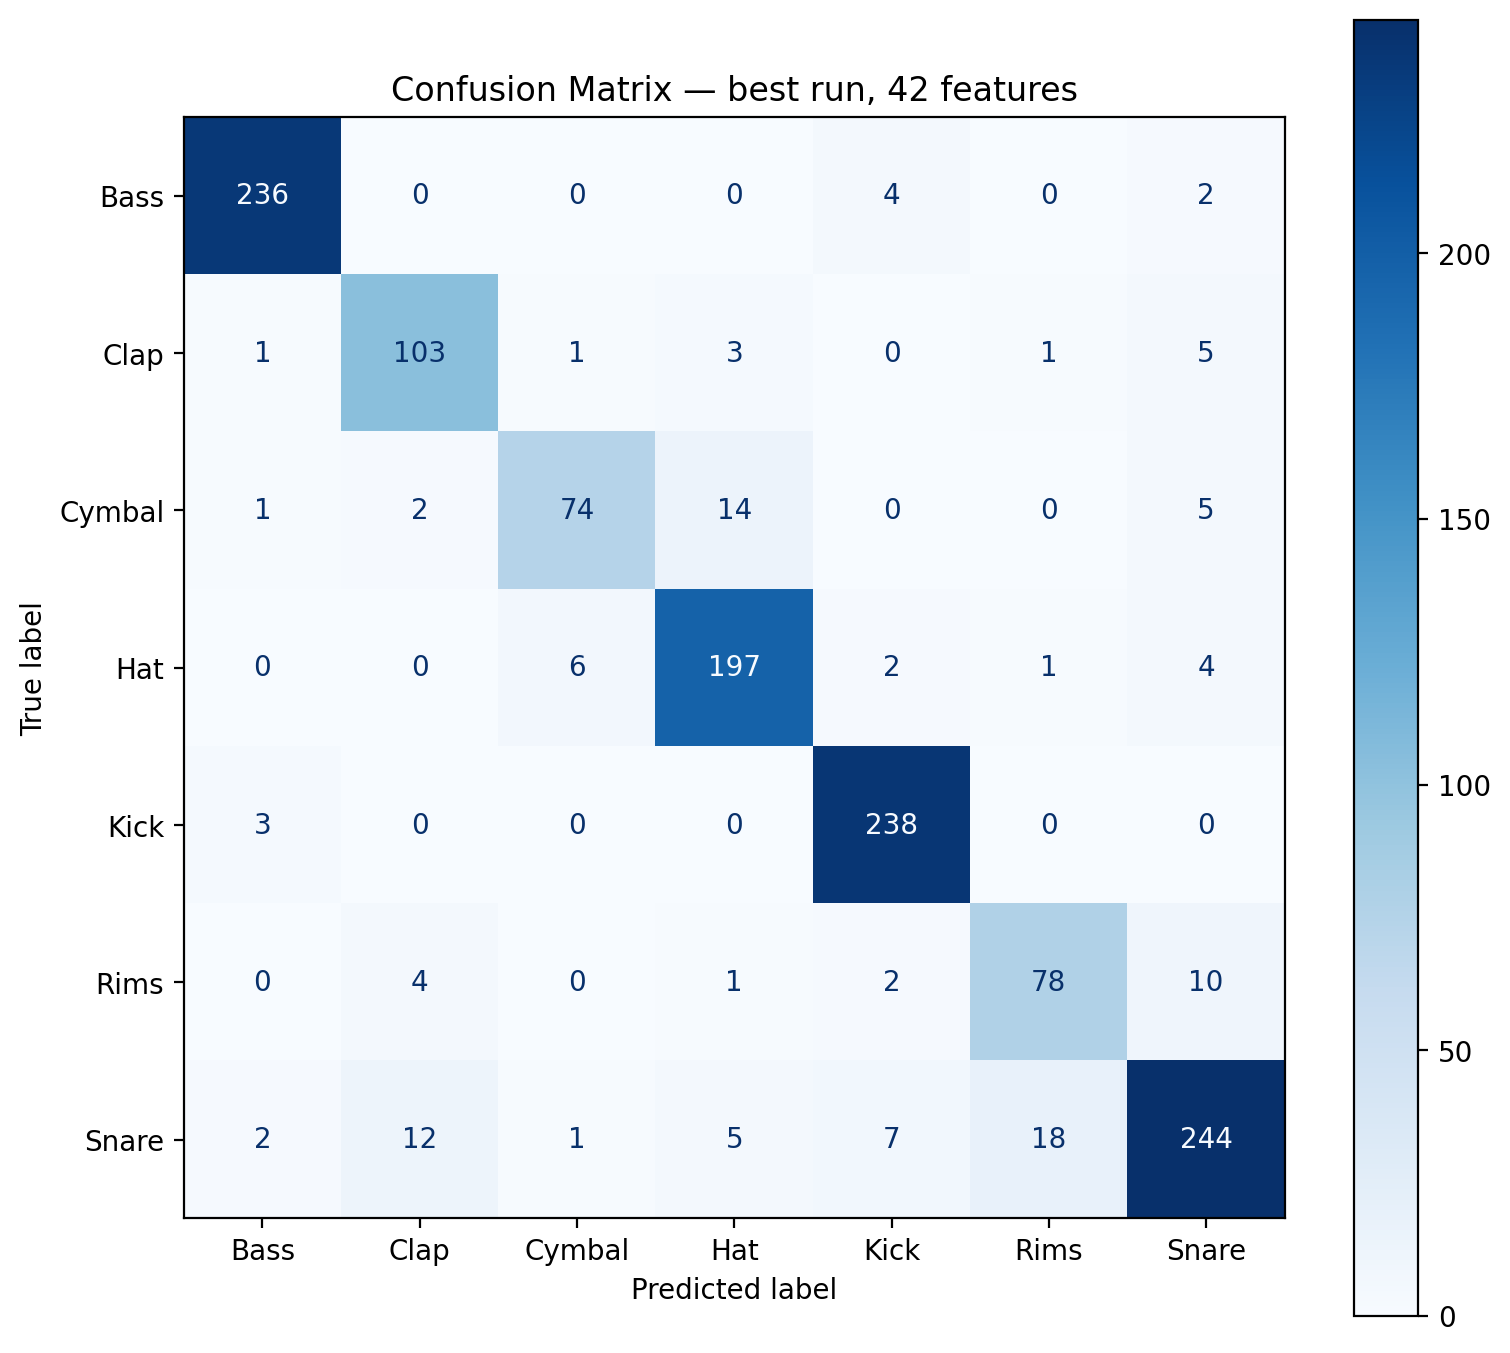

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 7), dpi=200)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=True)
ax.set_title('Confusion Matrix — best run, 42 features')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix_42feats.png',
            dpi=300, bbox_inches='tight')
plt.show()


## 9. Training curves — best run + run-to-run variability
The shaded band shows min–max across all 5 runs, providing a visual indication of run-to-run variability.

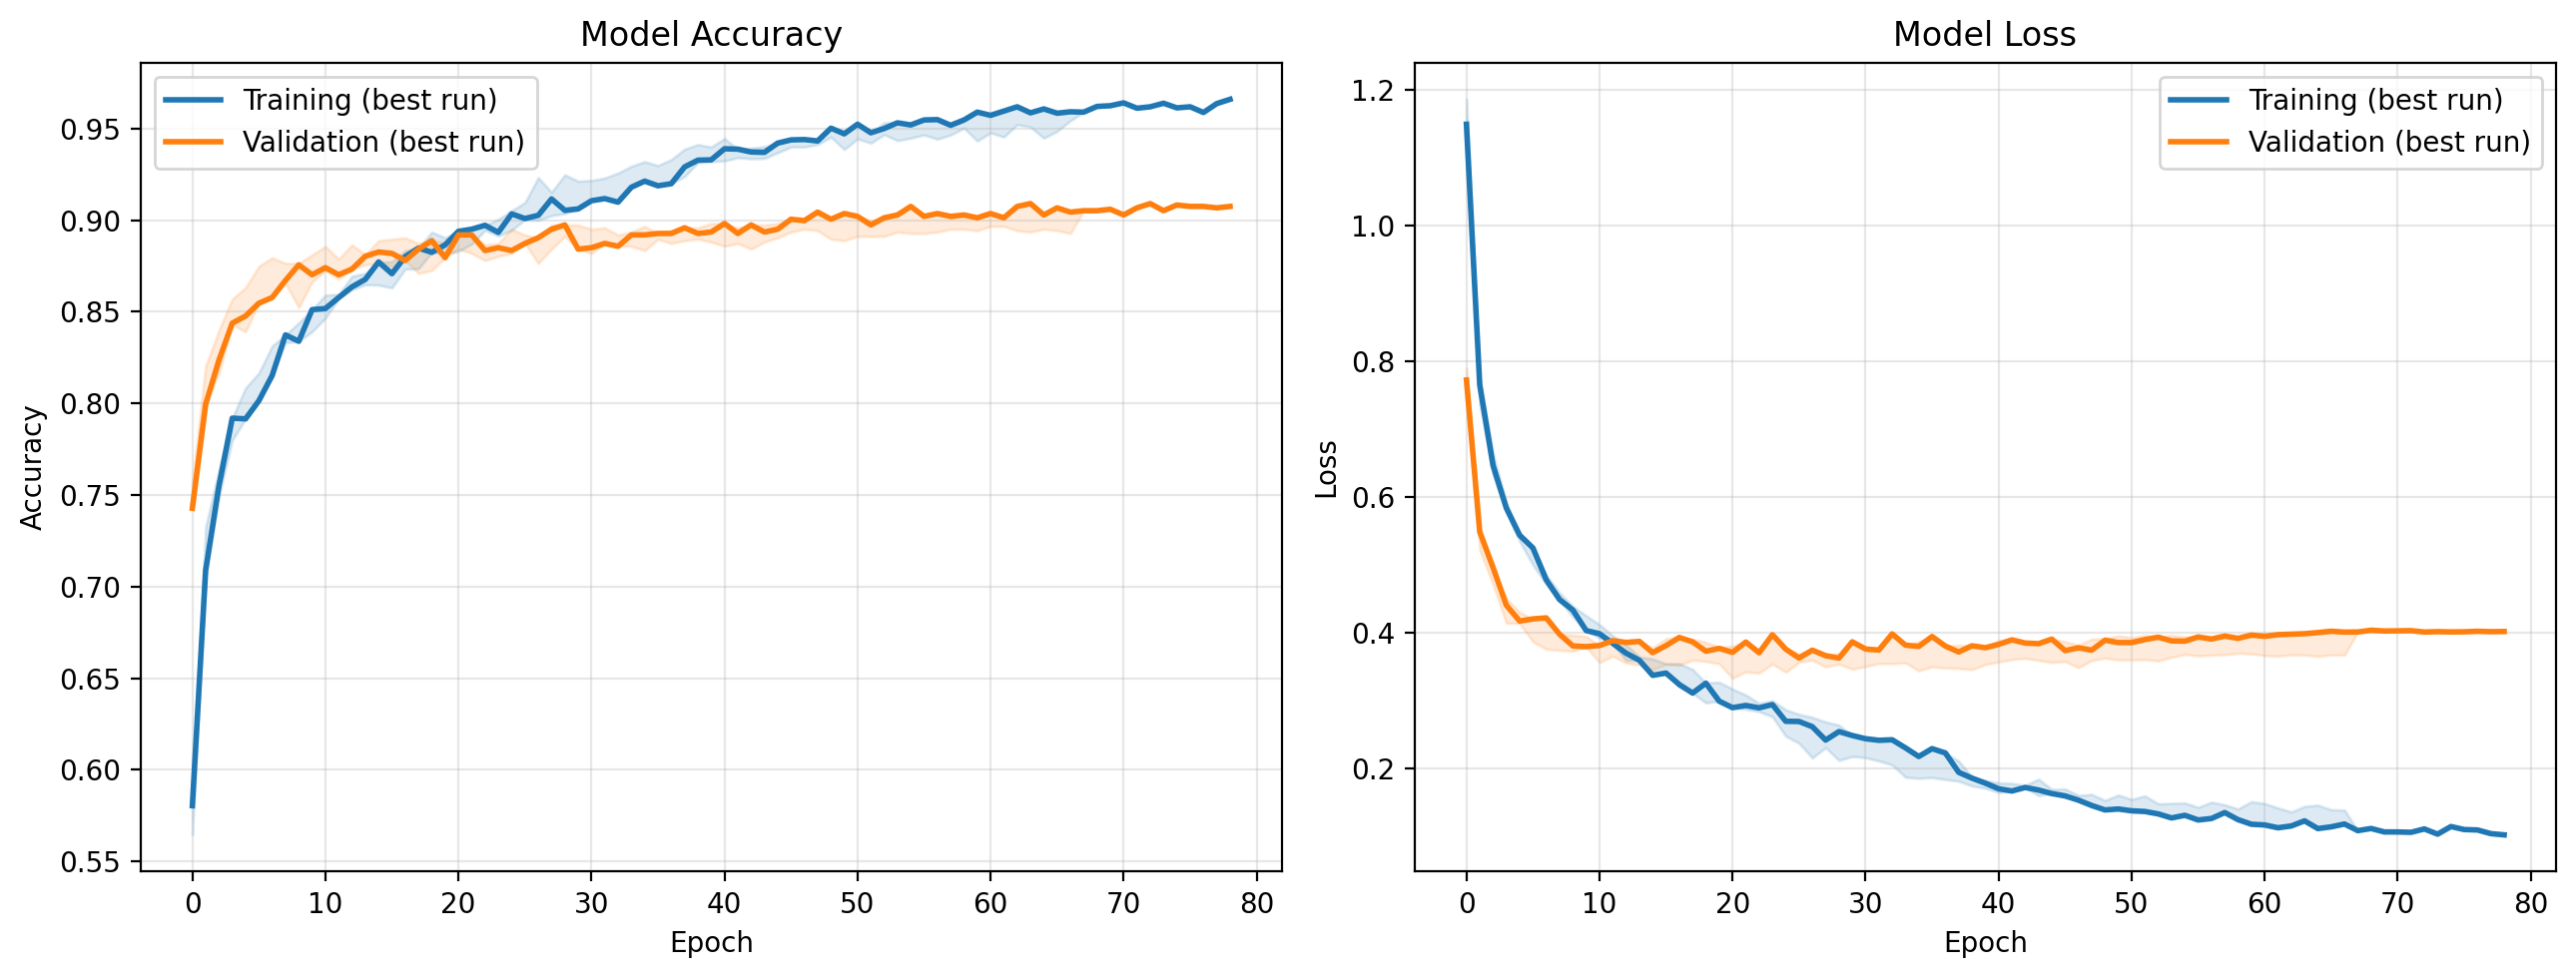

In [14]:
def pad_hist(hist_list, key):
    max_len = max(len(h[key]) for h in hist_list)
    arr = np.full((len(hist_list), max_len), np.nan)
    for i, h in enumerate(hist_list):
        arr[i, :len(h[key])] = h[key]
    return arr

best_hist = all_histories[best_run_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=200)

# --- Accuracy ---
ax = axes[0]
train_all = pad_hist(all_histories, 'accuracy')
val_all   = pad_hist(all_histories, 'val_accuracy')
epochs_x  = np.arange(train_all.shape[1])

ax.fill_between(epochs_x, np.nanmin(train_all, 0), np.nanmax(train_all, 0),
                alpha=0.15, color='tab:blue')
ax.fill_between(epochs_x, np.nanmin(val_all, 0), np.nanmax(val_all, 0),
                alpha=0.15, color='tab:orange')
ax.plot(best_hist['accuracy'],     label='Training (best run)',   color='tab:blue',   linewidth=2)
ax.plot(best_hist['val_accuracy'], label='Validation (best run)', color='tab:orange', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy'); ax.grid(True, alpha=0.3); ax.legend()

# --- Loss ---
ax = axes[1]
train_all = pad_hist(all_histories, 'loss')
val_all   = pad_hist(all_histories, 'val_loss')
epochs_x  = np.arange(train_all.shape[1])

ax.fill_between(epochs_x, np.nanmin(train_all, 0), np.nanmax(train_all, 0),
                alpha=0.15, color='tab:blue')
ax.fill_between(epochs_x, np.nanmin(val_all, 0), np.nanmax(val_all, 0),
                alpha=0.15, color='tab:orange')
ax.plot(best_hist['loss'],     label='Training (best run)',   color='tab:blue',   linewidth=2)
ax.plot(best_hist['val_loss'], label='Validation (best run)', color='tab:orange', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Model Loss'); ax.grid(True, alpha=0.3); ax.legend()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_curves_42feats.png',
            dpi=300, bbox_inches='tight')
plt.show()


## Done

Next steps:
1. Paste the `AGGREGATE RESULTS` block, `PER-CLASS F1` block, and the `PER-RUN RESULTS` table back to the conversation.
2. We then run feature-importance analysis on `best_42feats.h5` to obtain the top-20 and top-10 feature lists.
3. Two further training notebooks (top-20 and top-10) will mirror this structure with the same 5-seed protocol.
